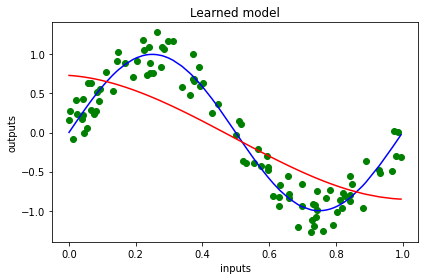

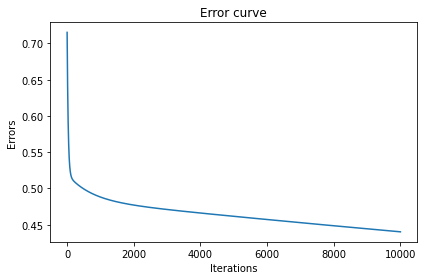

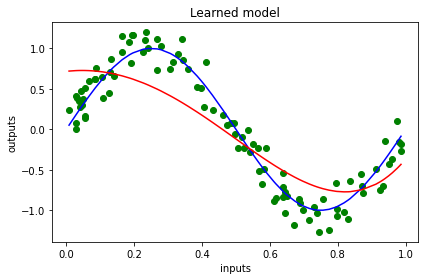

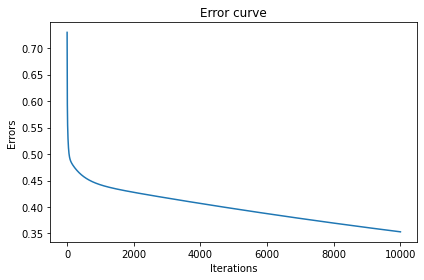

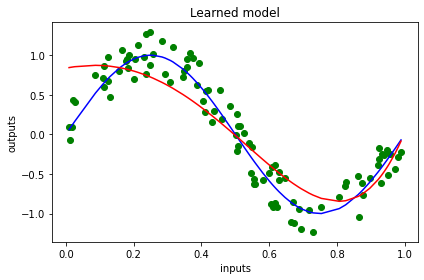

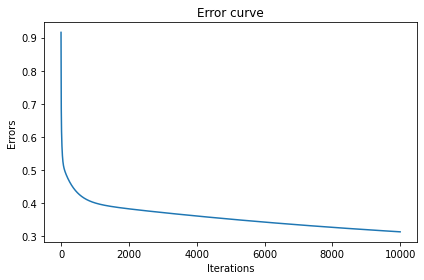

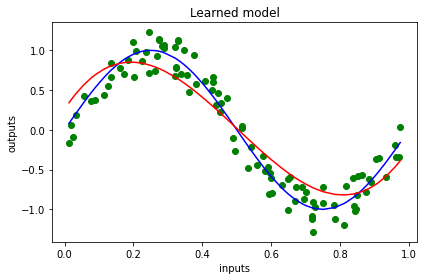

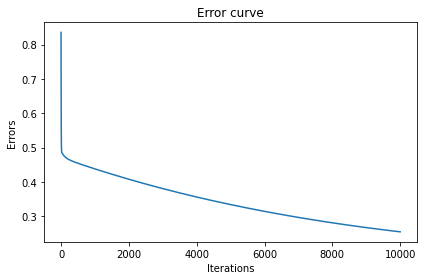

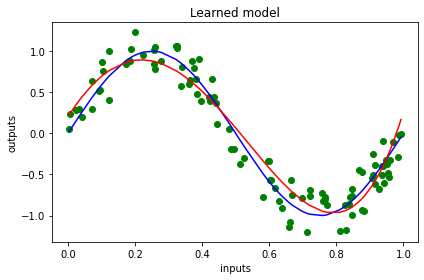

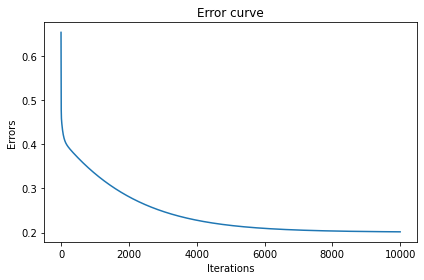

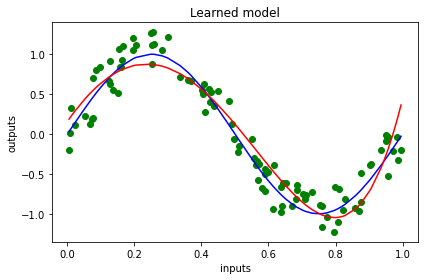

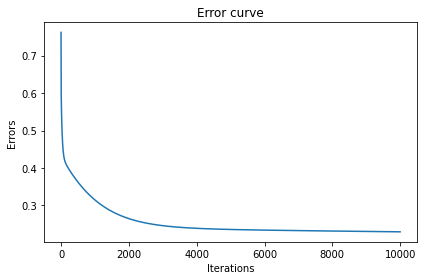

[0.15775752969665988, 6.024670609616, -12.019567677513104, -3.8148869209511536, 3.833805598991956, 6.258636840886849]


In [8]:
# -*- coding: utf-8 -*-

import random
import math
import matplotlib.pyplot as plt
import collections

def assign_weights_randomly(degree_of_polynomial):
    weights = []
    for i in range(0, degree_of_polynomial+1):
        weight_i = random.uniform(-0.5, 0.5)
        weights.append(weight_i)
    return weights

def generate_random_data(data_count):
    data_points = []
    inputs = []
    for i in range(0, data_count):
        x_i = random.uniform(0,1)
        # Prevent multiple similar inputs
        while (x_i in inputs):
            x_i = random.uniform(0,1)
        y_i = math.sin(2*math.pi*x_i) + random.uniform(-0.3, 0.3)
        data_points.append((x_i, y_i))
        inputs.append(x_i)
    return data_points

def polynomial(weights, x):
    output = weights[0]
    for i in range(1, len(weights)):
        output += weights[i]*math.pow(x, i)
    return output

def update_weights(data_points, weights, learning_rate):
    degree_of_polynomial = len(weights) - 1
    for i in range(1, len(data_points)+1):
        data_tuple = data_points[i-1]
        x_i = data_tuple[0]
        y_i = data_tuple[1]
        for j in range(0, degree_of_polynomial+1):
            weights[j] = weights[j] +  learning_rate * (y_i - polynomial(weights, x_i)) * math.pow(x_i, j) 
    return weights
            
def train_model(degree_of_polynomial, learning_rate, number_of_iterations):
    data_count = 100
    
    data = generate_random_data(data_count)
    weights = assign_weights_randomly(degree_of_polynomial)
    
    errors = []
    for i in range(0, number_of_iterations):
        weights = update_weights(data, weights, learning_rate)
        errors.append(error_RMS(weights, learning_rate, data))
    
    return weights, errors, data
        
def error_RMS(weights, learning_rate, data):
    accumulated_error = 0
    for i in range(0, len(data)):
        data_tuple = data[i]
        x_i = data_tuple[0]
        y_i = data_tuple[1]
        accumulated_error += (polynomial(weights, x_i) - y_i)*(polynomial(weights, x_i) - y_i)
    expected_error = accumulated_error/2
    return math.sqrt(2*expected_error/len(data))

def error_curve(errors_progress):
    iterations = list(range(0, len(errors_progress)))
    plt.plot(iterations,errors_progress)
    plt.title('Error curve')
    plt.xlabel('Iterations')
    plt.ylabel('Errors')
    plt.show()

def report_graph(data, weights):
    inputs = []
    ground_truths = []
    dataDict = {}
    modelDict = {}
    for i in range(0, len(data)):
        data_tuple = data[i]
        x_i = data_tuple[0]
        dataDict[x_i] = data_tuple[1]
        modelDict[x_i] = polynomial(weights, x_i)
    dataDict = collections.OrderedDict(sorted(dataDict.items()))
    modelDict = collections.OrderedDict(sorted(modelDict.items()))
    inputs = list(dataDict.keys())
    ground_truths = dataDict.values()
    predicted_values = list(modelDict.values())
    sine_func_values = []
    for input_x in inputs:
        sine_func_val = math.sin(2*math.pi*input_x)
        sine_func_values.append(sine_func_val)
    plt.rcParams["figure.autolayout"] = True
    plt.scatter(inputs, ground_truths, label = "Data points", c='green')
    plt.plot(inputs, sine_func_values, label = "Sine function", c='blue')
    plt.plot(inputs, predicted_values, label = "Learned function", c='red')
    plt.title('Learned model')
    plt.xlabel('inputs')
    plt.ylabel('outputs')
    plt.show()

def generate_report(errors_progress, data, weights):
    report_graph(data, weights)
    error_curve(errors_progress)
    
def main(degree_of_polynomial, learning_rate):
    number_of_iterations = 10000
    trained_weights, errors_progress, data = train_model(degree_of_polynomial, learning_rate, number_of_iterations)
    generate_report(errors_progress, data, trained_weights)
    return trained_weights

# Degree of polynomial = 3, learning rate = 0.001
weights = main(3, 0.001)
# Degree of polynomial = 4, learning rate = 0.001
weights = main(4, 0.001)
# Degree of polynomial = 5, learning rate = 0.001
weights = main(5, 0.001)
# Degree of polynomial = 3, learning rate = 0.01
weights = main(3, 0.01)
# Degree of polynomial = 4, learning rate = 0.01
weights = main(4, 0.01)
# Degree of polynomial = 5, learning rate = 0.01
weights = main(5, 0.01)
print(weights)
